# Description 

This script allows to generate a set of figures relating to a variable for a lakes in lakes_cci version 2.1.0 based in its id.

It is adapted to be executed via Binder (https://mybinder.org/)


INPUT:
    <ul>
    <li>The identifier of the lake. The id of the lake is indicated 
      in the csv file containing lake metadata. This file is available 
      at the project website:
      https://admin.climate.esa.int/documents/2607/lakescci_v2.1.0_metadata.csv </li>
    <li>Name of the variable in the netCDF files</li>
    <li>Land mask: the netCDF file containing the mask of the lakes in CCI datase (no changes in the landmask between v2.0.1 and v2.1) is available at: https://dap.ceda.ac.uk/neodc/esacci/lakes/data/lake_products/L3S/v2.0.1/ESA_CCI_static_lake_mask_v2.0.1.nc</li>
    <li>First/last dates</li>
    <li>Version of the dataset to be download (default value 2.1.0).</li>
    </ul>
    
 The complete dataset is available at CEDA : https://catalogue.ceda.ac.uk/uuid/7fc9df8070d34cacab8092e45ef276f1/

 Reference: Carrea, L.; Crétaux, J.-F.; Liu, X.; Wu, Y.; Bergé-Nguyen,
 M.; Calmettes, B.; Duguay, C.; Jiang, D.; Merchant, C.J.; Mueller, D.;
 Selmes, N.; Simis, S.; Spyrakos, E.; Stelzer, K.; Warren, M.; Yesou,
 H.; Zhang, D. (2022): ESA Lakes Climate Change Initiative (Lakes_cci):
 Lake products, Version 2.1.0. NERC EDS Centre for Environmental Data
 Analysis, date of citation.
 https://dx.doi.org/10.5285/7fc9df8070d34cacab8092e45ef276f1
 
    
 WARNING: This script is a beta version. All controls on the input parameters
 are not (yet) available. If you find a bug, have a question or a
 suggestion, don't hesitate to contact us, it will be much appreciated :
 cci_lakes.contact@groupcls.com



# key variables

Lakes_cci dataset is a merged product containing multiple variables from different thematic ECVs. The key variables are as follow:

<b>Lake Water Level (LWL):</b>
<ul><li>water_surface_height_above_reference_datum</li></ul>

<b>Lake Water Extent (LWE):</b>
<ul><li>lake_surface_water_extent</li></ul>

<b>Lake Ice Cover (LIC):</b>
<ul><li>lake_ice_cover_class</li></ul>


<b>Lake Surface Water Temperature (LSWT):</b>
<ul><li>lake_surface_water_temperature</li></ul>


<b>Lake Water Leaving Reflectance (LWLR):</b>
<ul><li>chla_mean</li>
<li>turbidity_mean</li>
<li>Rwxxx with xxx: 400, 412, 443, 469, 490, 510, 531, 547, 560, 620, 645, 665, 674, 681, 709, 754, 779, 859, 885, 900, 1020</li></ul>


In [27]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import datetime
from tqdm.notebook import tqdm
import time

In [28]:
# list of variables in the netCDF files
lakes_cci_variables = ['Rw1020', 'Rw1020_uncertainty_relative','Rw1020_uncertainty_relative_unbiased',
                       'Rw400','Rw400_uncertainty_relative','Rw400_uncertainty_relative_unbiased',
                       'Rw412','Rw412_uncertainty_relative','Rw412_uncertainty_relative_unbiased',
                       'Rw443','Rw443_uncertainty_relative','Rw443_uncertainty_relative_unbiased',
                       'Rw469','Rw469_uncertainty_relative','Rw469_uncertainty_relative_unbiased',
                       'Rw490','Rw490_uncertainty_relative','Rw490_uncertainty_relative_unbiased',
                       'Rw510','Rw510_uncertainty_relative','Rw510_uncertainty_relative_unbiased',
                       'Rw547','Rw547_uncertainty_relative','Rw547_uncertainty_relative_unbiased',
                       'Rw560','Rw560_uncertainty_relative','Rw560_uncertainty_relative_unbiased',
                       'Rw620','Rw620_uncertainty_relative','Rw620_uncertainty_relative_unbiased',
                       'Rw531','Rw531_uncertainty_relative','Rw531_uncertainty_relative_unbiased',
                       'Rw645','Rw645_uncertainty_relative','Rw645_uncertainty_relative_unbiased',
                       'Rw665','Rw665_uncertainty_relative','Rw665_uncertainty_relative_unbiased',
                       'Rw674','Rw674_uncertainty_relative','Rw674_uncertainty_relative_unbiased',
                       'Rw681','Rw681_uncertainty_relative','Rw681_uncertainty_relative_unbiased',
                       'Rw709','Rw709_uncertainty_relative','Rw709_uncertainty_relative_unbiased',
                       'Rw754','Rw754_uncertainty_relative','Rw754_uncertainty_relative_unbiased',
                       'Rw779','Rw779_uncertainty_relative','Rw779_uncertainty_relative_unbiased',
                       'Rw859','Rw859_uncertainty_relative','Rw859_uncertainty_relative_unbiased',
                       'Rw885','Rw885_uncertainty_relative','Rw885_uncertainty_relative_unbiased',
                       'Rw900','Rw900_uncertainty_relative','Rw900_uncertainty_relative_unbiased',  
                       'chla_mean','chla_uncertainty','turbidity_mean','turbidity_uncertainty',
                       'lake_ice_cover_class','lake_ice_cover_flag','lake_ice_cover_uncertainty',
                       'lake_surface_water_temperature','lswt_uncertainty','lswt_quality_level',
                       'water_surface_height_above_reference_datum','lwl_uncertainty','lwl_quality_flag',
                       'lake_surface_water_extent','lwe_uncertainty','lwe_quality_flag',
                       'time', 'lat', 'lon']

In [29]:
###########################################################################################
# input parameters
###########################################################################################   

# lakes mask file 
maskfile = 'ESA_CCI_static_lake_mask_v2.1.nc'

# Id for lake kangaarsuup Taresua
lake_id = 300003969

# all three lake surface water temperature related vars
#varname = 'lake_surface_water_temperature' 
#varname = 'lswt_uncertainty'
#varname = 'lswt_quality_level'
#varname = 'lake_ice_cover_flag'
varname = 'lake_ice_cover_class'


# defining the period of time in string format: YYYY-MM-DD
# dates values must be between 1992-09-26 and 2020-12-31

mindate = '2021-01-01'
maxdate = '2021-12-31'

In [30]:
# test if dates are in the temporal coverage

mindate = datetime.datetime.strptime(mindate, '%Y-%m-%d')
maxdate = datetime.datetime.strptime(maxdate, '%Y-%m-%d')
mindate = max([mindate, datetime.datetime(1992,9,26)])
maxdate = min([maxdate, datetime.datetime(2022,12,31)])


In [31]:
# test if varname in list of variables
if not varname in lakes_cci_variables:
    print (f'the varname "{varname}" does not exist in lakes_cci dataset' )

In [32]:
##################################################################################################
# create mask based on lake_id, source: https://rmets.onlinelibrary.wiley.com/doi/10.1002/gdj3.32
##################################################################################################
mask_nc = nc.Dataset(maskfile)

minx = []
maxx = []
miny = []
maxy = []

nc_var = mask_nc.variables["CCI_lakeid"]
shape =  nc_var.shape

step = int(np.ceil(shape[0] / 10))
steps = list(range(0, shape[0] + step, step))

i = steps[0]
for j in steps[1:]:
    mask = nc_var[i:j, :]
    mask_ind = np.where(mask == lake_id)

    if mask_ind[0].size > 0 or mask_ind[1].size > 0:
        minx.append(np.min(mask_ind[1][:]) - 1)
        maxx.append(np.max(mask_ind[1][:]) + 1)
        miny.append(np.min(mask_ind[0][:]) - 1 + i)
        maxy.append(np.max(mask_ind[0][:]) + 1 + i )
    del mask
    i = j

minx = np.min(minx)
maxx = np.max(maxx)
miny = np.min(miny)
maxy = np.max(maxy)

mask_lake =nc_var[miny : maxy + 1, minx : maxx + 1]
mask_lake[mask_lake != lake_id] = 0
mask_lake[mask_lake == lake_id] = 1


lon = mask_nc.variables['lon'][minx:maxx + 1]
lat = mask_nc.variables['lat'][miny:maxy + 1]



mask_nc.close()

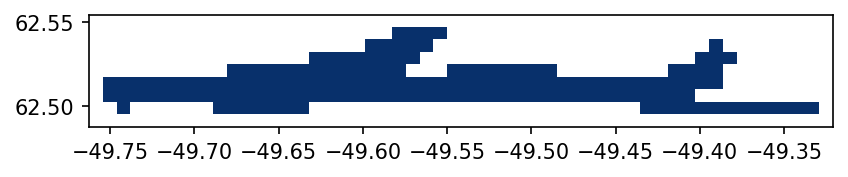

lon min:-49.76250076293945
lon max:-49.32083511352539


In [33]:

###################################################################
# Plot lake mask
###################################################################

plt.imshow(np.flipud(mask_lake), extent=[lon[0], lon[-1], lat[0], lat[-1]], cmap = 'Blues_r')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()

print(f"lon min:{lon[0]}")
print(f"lon max:{lon[-1]}")

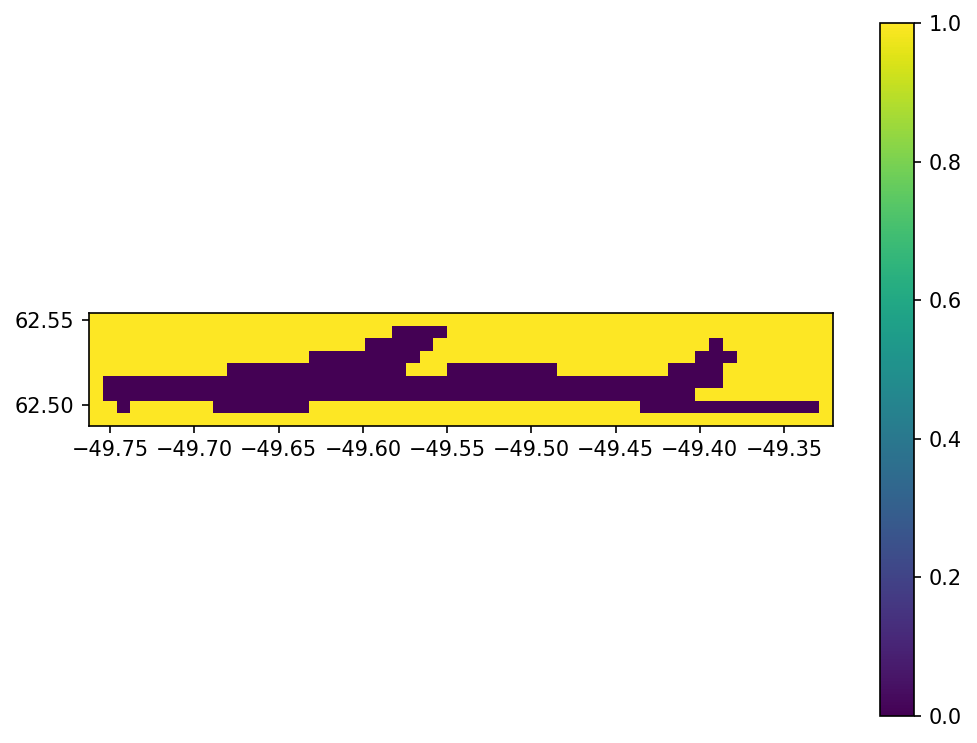

[[ True  True  True  True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True]
 [ True  True False  True  True  True  True  True  True False False False False False False
  False  True  True  True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True False False False False False
  False False False False False False False False  True]
 [ True False False False False False False False False False False False False False False
  False False False False False False False False False False False False False False False
  False False False False False False False False False False False False False False  True
   True  True  True  True  True  True  True  True  True]
 

<xarray.DataArray 'lake_mask' (lat: 9, lon: 54)> Size: 4kB
array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan],
       [nan, nan,  1., nan, nan, nan, nan, nan, nan,  1.,  1.,  1.,  1.,  1.,  1.,  1., nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1., nan],
       [nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan],
       [nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., nan, nan, nan, nan, nan,
        nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  1.,  1.,  1., nan, nan, nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        nan, nan, nan, nan, nan, nan, nan, nan,  1.,  1.,  1.,  1., nan, nan, nan, nan, nan,
        nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  1.,
         1.,  1.,  1.,  1.,  1.,  1.,  1., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  1.,  1.,  1., nan, nan, nan, nan,
        nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan,  1.,  1.,  1.,  1.,  1., nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  1., nan, nan, nan, nan, nan,
        nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan,  1.,  1.,  1.,  1., nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan]])
Coordinates:
  * lat      (lat) float32 36B 62.49 62.5 62.5 62.51 ... 62.53 62.54 62.55 62.55
  * lon      (lon) float32 216B -49.76 -49.75 -49.75 ... -49.34 -49.33 -49.32

In [34]:
# save the lon/lat to the lake_polygons folder (they are not saved anywhere else!)
np.savetxt("../lake_polygons/latidute_coords_lake_6.txt", lat)
np.savetxt("../lake_polygons/longitude_coords_lake_6.txt", lon)

mask_plot = np.array(mask_lake.mask)


import matplotlib.pyplot as plt

mask_plot = np.array(mask_lake.mask)

plt.figure(figsize=(8, 6))
plt.imshow(np.flipud(mask_plot), extent=[lon[0], lon[-1], lat[0], lat[-1]])
plt.colorbar()
plt.show()

### the lake in the plot is upside down
print(mask_plot)

### make the lon lat values:
mask_with_coords = xr.DataArray(
    mask_lake,
    coords={
        "lat": lat,
        "lon": lon
    },
    dims=["lat", "lon"],
    name="lake_mask"
)

# then write it to disk:
mask_with_coords.to_netcdf(f"lake_6_mask_with_buffer_and_coords.nc") # this works, has been double checked in QGIS, EPSG is 4326

mask_with_coords

Download process: this can take longtime depending on the selected dates. Each daily file needs to be access to verify if there is (or not) data available for the selected lake.

In [26]:
# data storage
data = []
version = 2.1  # define version of the dataset

# total number of days
days_total = (maxdate - mindate).days + 1
start_time = time.perf_counter() # start time

# start loop
for i, data_date in enumerate(
    np.arange(mindate.toordinal(), maxdate.toordinal() + 1)):
    current_date = datetime.datetime.fromordinal(data_date)
    date_str = current_date.strftime("%Y%m%d")

    path = (f'https://data.cci.ceda.ac.uk/thredds/dodsC/'
        f'esacci/lakes/data/lake_products/L3S/v{version}/merged_product/'
        f'{current_date.year}/{current_date.month:02}/'
        f'ESACCI-LAKES-L3S-LK_PRODUCTS-MERGED-{date_str}-fv{version}.0.nc?{varname}')

    daily_data = xr.open_dataset(path)
    daily_data = daily_data.isel({"lat": slice(miny, maxy),"lon": slice(minx, maxx)})

    data.append(daily_data)

    # progress 
    percent = (i + 1) / days_total * 100
    print(f"\rProcessing: {percent:.1f}% ({i + 1}/{days_total})",end="",flush=True)

# all datasets together
ds_data = xr.concat(data, dim="time")

# end time
elapsed_time = time.perf_counter() - start_time
hours, remainder = divmod(elapsed_time, 3600)
minutes, seconds = divmod(remainder, 60)

print(f"\nIt took {hours}h, {minutes}min and {seconds}sec.") # roughly one day = 1sec

Processing: 2.2% (8/365)

KeyboardInterrupt: 

In [ ]:
# save data to folder:
ds_data.to_netcdf("processed_data/lake_ice_cover_class_2018.nc")



### make a loop for several varnames and then later years to save


In [35]:
import xarray as xr
import numpy as np
import datetime
import time
import os

# define date range
mindate = '2022-01-01'
maxdate = '2022-12-31'

# test if they are in valid time range & convert 
mindate = datetime.datetime.strptime(mindate, '%Y-%m-%d')
maxdate = datetime.datetime.strptime(maxdate, '%Y-%m-%d')
mindate = max([mindate, datetime.datetime(1992,9,26)])
maxdate = min([maxdate, datetime.datetime(2022,12,31)])

# Variables to download
varnames_list = [
    'lake_surface_water_temperature',
    'lswt_uncertainty',
    'lswt_quality_level',
    'lake_ice_cover_flag',
    'lake_ice_cover_class'
]

# Dataset version
version = 2.1

# Output folder
output_folder = "processed_data/2022"
os.makedirs(output_folder, exist_ok=True)

# Total number of days
days_total = (maxdate - mindate).days + 1

# Start overall timer
overall_start = time.perf_counter()

# Loop over variables
for varname in varnames_list:

    print(f"\n{'='*60}")
    print(f"Downloading variable: {varname}")
    print(f"{'='*60}")

    start_time = time.perf_counter()

    # Storage for daily datasets
    data = []

    # Loop over dates
    for i, data_date in enumerate(
        np.arange(mindate.toordinal(), maxdate.toordinal() + 1)
    ):

        current_date = datetime.datetime.fromordinal(data_date)
        date_str = current_date.strftime("%Y%m%d")

        path = (
            f'https://data.cci.ceda.ac.uk/thredds/dodsC/'
            f'esacci/lakes/data/lake_products/L3S/v{version}/merged_product/'
            f'{current_date.year}/{current_date.month:02}/'
            f'ESACCI-LAKES-L3S-LK_PRODUCTS-MERGED-{date_str}-fv{version}.0.nc?{varname}'
        )

        # Open daily dataset
        daily_data = xr.open_dataset(path)

        # Select spatial subset
        daily_data = daily_data.isel({
            "lat": slice(miny, maxy),
            "lon": slice(minx, maxx)
        })

        data.append(daily_data)

        # Progress
        percent = (i + 1) / days_total * 100
        print(
            f"\r{varname}: {percent:.1f}% "
            f"({i + 1}/{days_total})",
            end="",
            flush=True
        )

    # Concatenate all days
    ds_data = xr.concat(data, dim="time")

    # Output filename
    output_file = os.path.join(
        output_folder,
        f"{varname}_2018.nc"
    )

    # Save to NetCDF
    ds_data.to_netcdf(output_file)

    # Close datasets
    ds_data.close()
    for ds in data:
        ds.close()

    # Timing
    elapsed_time = time.perf_counter() - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)

    print(
        f"\nFinished {varname} -> {output_file}"
    )
    print(
        f"Time: {int(hours)}h, {int(minutes)}min, {seconds:.1f}sec"
    )

# Overall timing
overall_elapsed = time.perf_counter() - overall_start
hours, remainder = divmod(overall_elapsed, 3600)
minutes, seconds = divmod(remainder, 60)

print(
    f"\nAll variables finished in "
    f"{int(hours)}h, {int(minutes)}min, {seconds:.1f}sec."
)


lake_surface_water_temperature: 100.0% (365/365)
Finished lake_surface_water_temperature -> processed_data/2022\lake_surface_water_temperature_2018.nc
Time: 0h, 10min, 26.0sec

lswt_uncertainty: 100.0% (365/365)
Finished lswt_uncertainty -> processed_data/2022\lswt_uncertainty_2018.nc
Time: 0h, 11min, 16.6sec

lswt_quality_level: 100.0% (365/365)
Finished lswt_quality_level -> processed_data/2022\lswt_quality_level_2018.nc
Time: 0h, 9min, 58.7sec

lake_ice_cover_flag: 100.0% (365/365)
Finished lake_ice_cover_flag -> processed_data/2022\lake_ice_cover_flag_2018.nc
Time: 0h, 9min, 49.3sec

lake_ice_cover_class: 100.0% (365/365)
Finished lake_ice_cover_class -> processed_data/2022\lake_ice_cover_class_2018.nc
Time: 0h, 9min, 46.0sec

All variables finished in 0h, 51min, 16.8sec.
